In [21]:
# install dependencies 
print("Installing dependencies...")
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates



import os 
from pathlib import Path
import warnings 
warnings.filterwarnings("ignore")

from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
import joblib


import logging
import sys
from pathlib import Path
from logging.handlers import RotatingFileHandler
from typing import Iterable

def get_logger(
    name: str = __name__,
    log_file: str = "app.log",
    level: int = logging.DEBUG,
    max_bytes: int = 5 * 1024 * 1024,
    backup_count: int = 3
) -> logging.Logger:
    """
    Buat logger yang siap pakai dengan output ke console + file.

    Args:
        name        : nama logger, biasanya __name__ dari modul yang memanggil
        log_file    : path file log
        level       : minimum level yang direkam (default: DEBUG)
        max_bytes   : ukuran max per file log sebelum di-rotate (default: 5MB)
        backup_count: jumlah file backup yang disimpan

    Returns:
        logging.Logger
    """

    # Make sure log file exists
    Path(log_file).parent.mkdir(parents=True, exist_ok=True)

    logger = logging.getLogger(name)

    # Avoid duplicate handler, if handler exists, use the existing handler
    if logger.handlers:
        return logger

    logger.setLevel(level)

    # logging format
    fmt = logging.Formatter(
        fmt="%(asctime)s | %(levelname)-8s | %(name)s | %(filename)s:%(lineno)d | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    )

    # handler for console stdout
    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.INFO)   # console: INFO ke atas saja
    console_handler.setFormatter(fmt)

    # handler for log file
    file_handler = RotatingFileHandler(
        log_file,
        maxBytes=max_bytes,
        backupCount=backup_count,
        encoding="utf-8"
    )
    file_handler.setLevel(logging.DEBUG)
    file_handler.setFormatter(fmt)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)

    return logger

# get root path of the project
PATH = Path(os.path.dirname(os.getcwd()))

print("All dependencies installed successfully!")
print(f"Current project directory: {PATH}")

Installing dependencies...
All dependencies installed successfully!
Current project directory: /Users/nadif/projects/hdi-recruitment


In [22]:
def read_data(input_path: str) -> pd.DataFrame:
    return pd.read_csv(input_path, parse_dates=["date"])

def build_features(df: pd.DataFrame, feature_store_path:str = None, drop_na=True) -> pd.DataFrame:
    df = df.copy().sort_values("date").reset_index(drop=True)

    target = "new_enterpriser_count"

    # build lag features
    for lag in [1, 2, 3, 7, 14, 21, 28]:
        df[f"lag_{lag}"] = df[target].shift(lag)

    # build rolling statistics
    for window in [7, 14, 30, 90]:
        df[f"rolling_mean_{window}"] = df[target].rolling(window).mean()
        df[f"rolling_std_{window}"] = df[target].rolling(window).std()

    # calendar features
    df["day_of_week_num"] = df["date"].dt.dayofweek
    df["day_of_month"] = df["date"].dt.day
    df["month"] = df["date"].dt.month 
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = (df["day_of_week_num"] > 4).astype(int)
    df["quarter"] = df["date"].dt.quarter

    # create new feature from is_promo_period information
    df["promo_lag1"] = df["is_promo_period"].shift(1).fillna(0)
    df["promo_next1"] = df["is_promo_period"].shift(-1).fillna(0)

    # capture multi-years trend with days_since_start feature
    df["days_since_start"] = (df['date'] - df['date'].min()).dt.days

    # save the data to feature store
    if feature_store_path:
        df.dropna().to_csv(feature_store_path, index=False)

    if drop_na:
        return df.dropna()
    else:
        return df

def performa_analysis(eval_test: dict, eval_train: dict) -> pd.DataFrame:
    rows = []
    for model_name in eval_train:
        train_result = eval_train[model_name]
        test_result = eval_test[model_name]
        ratio = test_result["mae"] / train_result["mae"]

        if ratio > 5:
            diagnosys = "Overfitting"
        elif ratio > 2:
            diagnosys = "Weak overfitting"
        else:
            diagnosys = "No overfitting"

        rows.append({
            "model_name":model_name,
            "train_mae": train_result["mae"],
            "test_mae": test_result["mae"],
            "train_rmse": train_result["rmse"],
            "test_rmse": test_result["rmse"],
            "train_mape": train_result["mape"],
            "test_mape": train_result["mape"],
            "diagnosys": diagnosys
        })

    df = pd.DataFrame(rows).set_index("model_name")

    return df

def visualize_actual_predict(date:pd.Series, y_pred, y, model, holdout=60):
    fig = plt.figure(figsize=(16,10))
    plt.plot(date, y, label="Actual", color="blue", linewidth=1.5)
    plt.plot(date, y_pred, label="Prediction", color="lightcoral", linewidth=1.5, linestyle="--")
    plt.fill_between(date, y, y_pred, alpha=0.1, color="orange")
    plt.title(f"Actual vs Predicted — Enterpriser Registrations (Holdout: {holdout} days)\nMODEL:{model}", fontsize=12, fontweight='bold')
    plt.ylabel("New Enterprisers/day")
    plt.legend()
    plt.grid()
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(plt.gca().xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



In [23]:
def train_compare(data_path:str, feature_store_path:str, models_dict:dict, holdout_days=60) -> None:
    logger = get_logger(log_file="logs/train.log")
    try:
        logger.info("Reading data for training...")
        df = pd.read_csv(data_path, parse_dates=["date"])
        logger.info(f"{df.shape[0]} rows and {df.shape[1]} columns loaded!")

        logger.info("Building features for training...")
        df_feat = build_features(df, feature_store_path)
        logger.info(f"Feature matrix: {df_feat.shape}")
        logger.info(f"Feature used: {[c for c in df_feat.columns if c not in df.columns.to_list()] + ["is_promo_period"]}")

        # train test split (using holdout days)
        logger.info("Splitting dataset for training and testing...")
        feature_cols = [c for c in df_feat.columns if c not in df.columns.to_list()] + ["is_promo_period"]
        target = "new_enterpriser_count"
        split_date = df_feat["date"].max() - pd.Timedelta(days=holdout_days)

        train_period = df_feat[df["date"] <= split_date]
        test_period = df_feat[df["date"] > split_date]

        X_train, y_train = train_period[feature_cols], train_period[target]
        X_test, y_test = test_period[feature_cols], test_period[target]

        logger.info(f"Train: {len(X_train)} days - From {train_period["date"].min().date()} to {train_period["date"].max().date()}")
        logger.info(f"Test: {len(X_test)} days - From {test_period["date"].min().date()} to {test_period["date"].max().date()}")

        results = {}
        results_train = {}
        for name, model in models_dict.items():
            logger.info(f"Training {name} model...")
            model.fit(X_train, y_train)
            y_pred = np.maximum(model.predict(X_test), 0)
            y_pred_train = np.maximum(model.predict(X_train), 0)
            mae = mean_absolute_error(y_test, y_pred)
            mae_train = mean_absolute_error(y_train, y_pred_train)
            rmse = root_mean_squared_error(y_test, y_pred)
            rmse_train = root_mean_squared_error(y_train, y_pred_train)
            mape = mean_absolute_percentage_error(y_test, y_pred)
            mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
            results[name] = {
                "mae" : round(mae,2),
                "rmse" : round(rmse,2),
                "mape" : round(mape,2),
            }
            results_train[name] = {
                 "mae" : round(mae_train,2),
                "rmse" : round(rmse_train,2),
                "mape" : round(mape_train,2),
            }
            joblib.dump(model, PATH / "models" / f"{name}.pkl")
            logger.info(f"Training {name} model finished!")
            visualize_actual_predict(test_period["date"], y_pred, y_test.values, name)
            except Exception as e:
                logger.warning(f"Model {name} has no feature importance function! Skipping")
            


        sorted_result = dict(sorted(results.items(), key=lambda x:x[1]["mae"]))
        sorted_result_train = dict(sorted(results_train.items(), key=lambda x:x[1]["mae"]))
        logger.info(f"Model performance on training data: {sorted_result_train} ")
        logger.info(f"Model performance on test data: {sorted_result}")
        display(performa_analysis(sorted_result,sorted_result_train))
    except FileNotFoundError as e:
        logger.error(f"File not found: {e}")
    except Exception as e:
        logger.critical(f"Unexpected error: {e}", exc_info=True)
    

SyntaxError: invalid syntax (656204408.py, line 54)

2026-06-29 23:46:11 | INFO     | __main__ | 4289691066.py:4 | Reading data for training...
2026-06-29 23:46:11 | INFO     | __main__ | 4289691066.py:6 | 1631 rows and 10 columns loaded!
2026-06-29 23:46:11 | INFO     | __main__ | 4289691066.py:8 | Building features for training...
2026-06-29 23:46:11 | INFO     | __main__ | 4289691066.py:10 | Feature matrix: (1542, 34)
2026-06-29 23:46:11 | INFO     | __main__ | 4289691066.py:11 | Feature used: ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30', 'rolling_std_30', 'rolling_mean_90', 'rolling_std_90', 'day_of_week_num', 'day_of_month', 'month', 'week_of_year', 'is_weekend', 'quarter', 'promo_lag1', 'promo_next1', 'days_since_start', 'is_promo_period']
2026-06-29 23:46:11 | INFO     | __main__ | 4289691066.py:14 | Splitting dataset for training and testing...
2026-06-29 23:46:11 | INFO     | __main__ | 4289691066.py:25 | Train: 1482 d

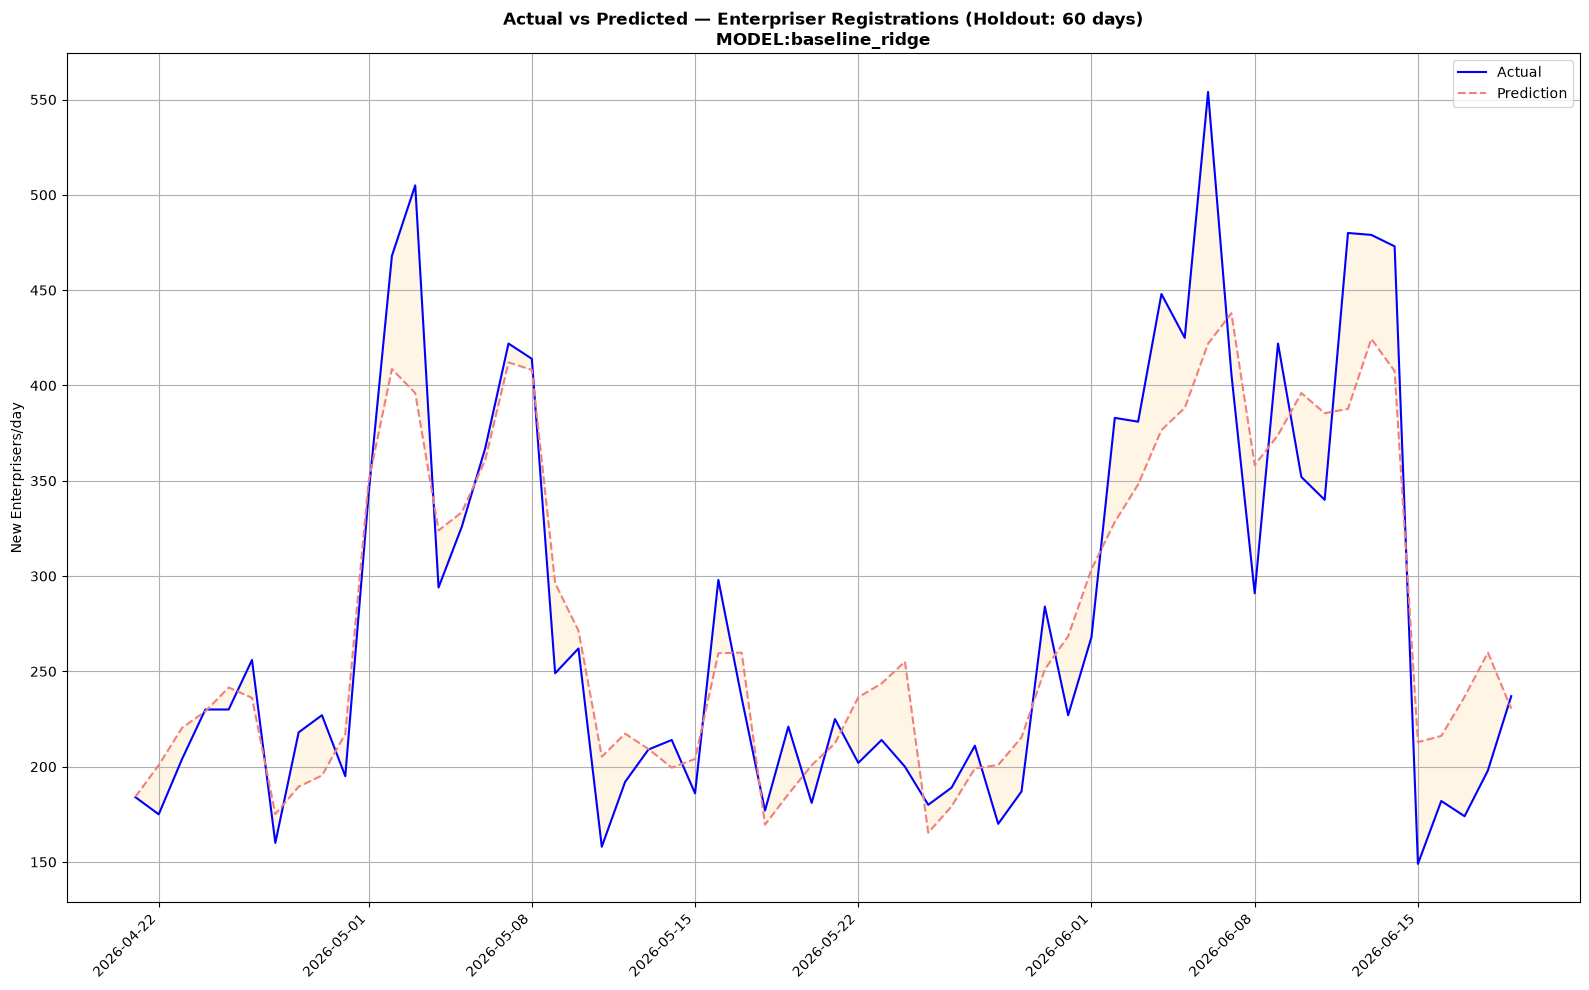

2026-06-29 23:46:11 | WARNING  | __main__ | 4289691066.py:58 | Model baseline_ridge has no feature importance function! Skipping
2026-06-29 23:46:11 | INFO     | __main__ | 4289691066.py:31 | Training xgboost model...
2026-06-29 23:46:12 | INFO     | __main__ | 4289691066.py:52 | Training xgboost model finished!


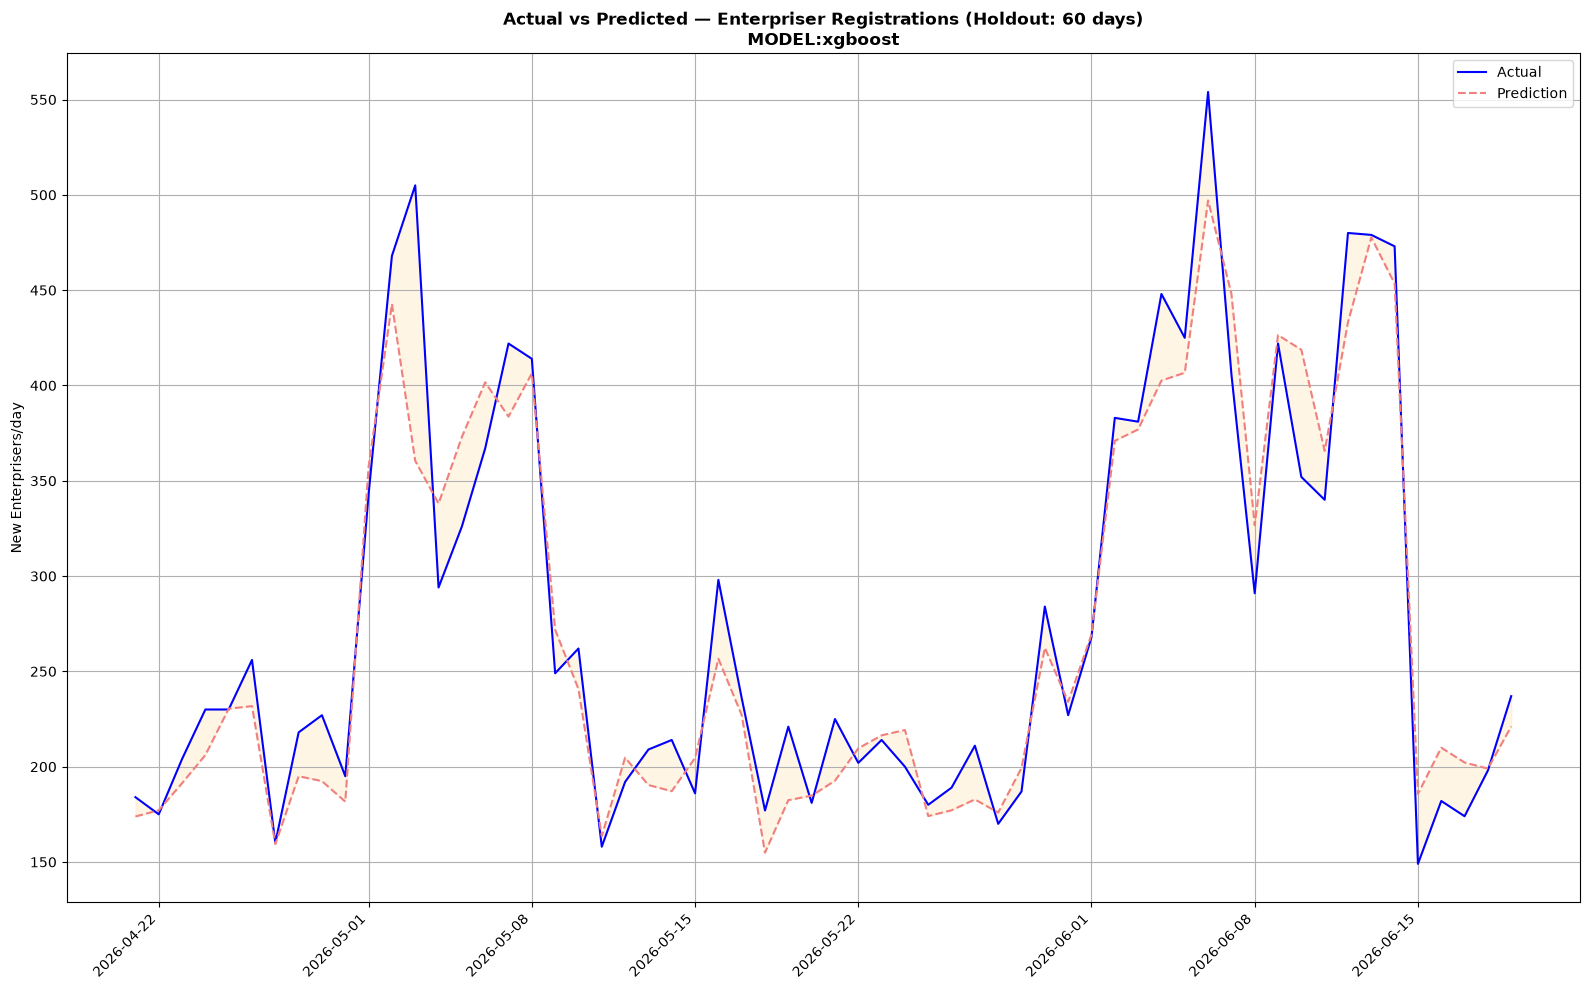

2026-06-29 23:46:12 | WARNING  | __main__ | 4289691066.py:58 | Model xgboost has no feature importance function! Skipping
2026-06-29 23:46:12 | INFO     | __main__ | 4289691066.py:31 | Training lgbm model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000587 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4198
[LightGBM] [Info] Number of data points in the train set: 1482, number of used features: 25
[LightGBM] [Info] Start training from score 224.213900
2026-06-29 23:46:12 | INFO     | __main__ | 4289691066.py:52 | Training lgbm model finished!


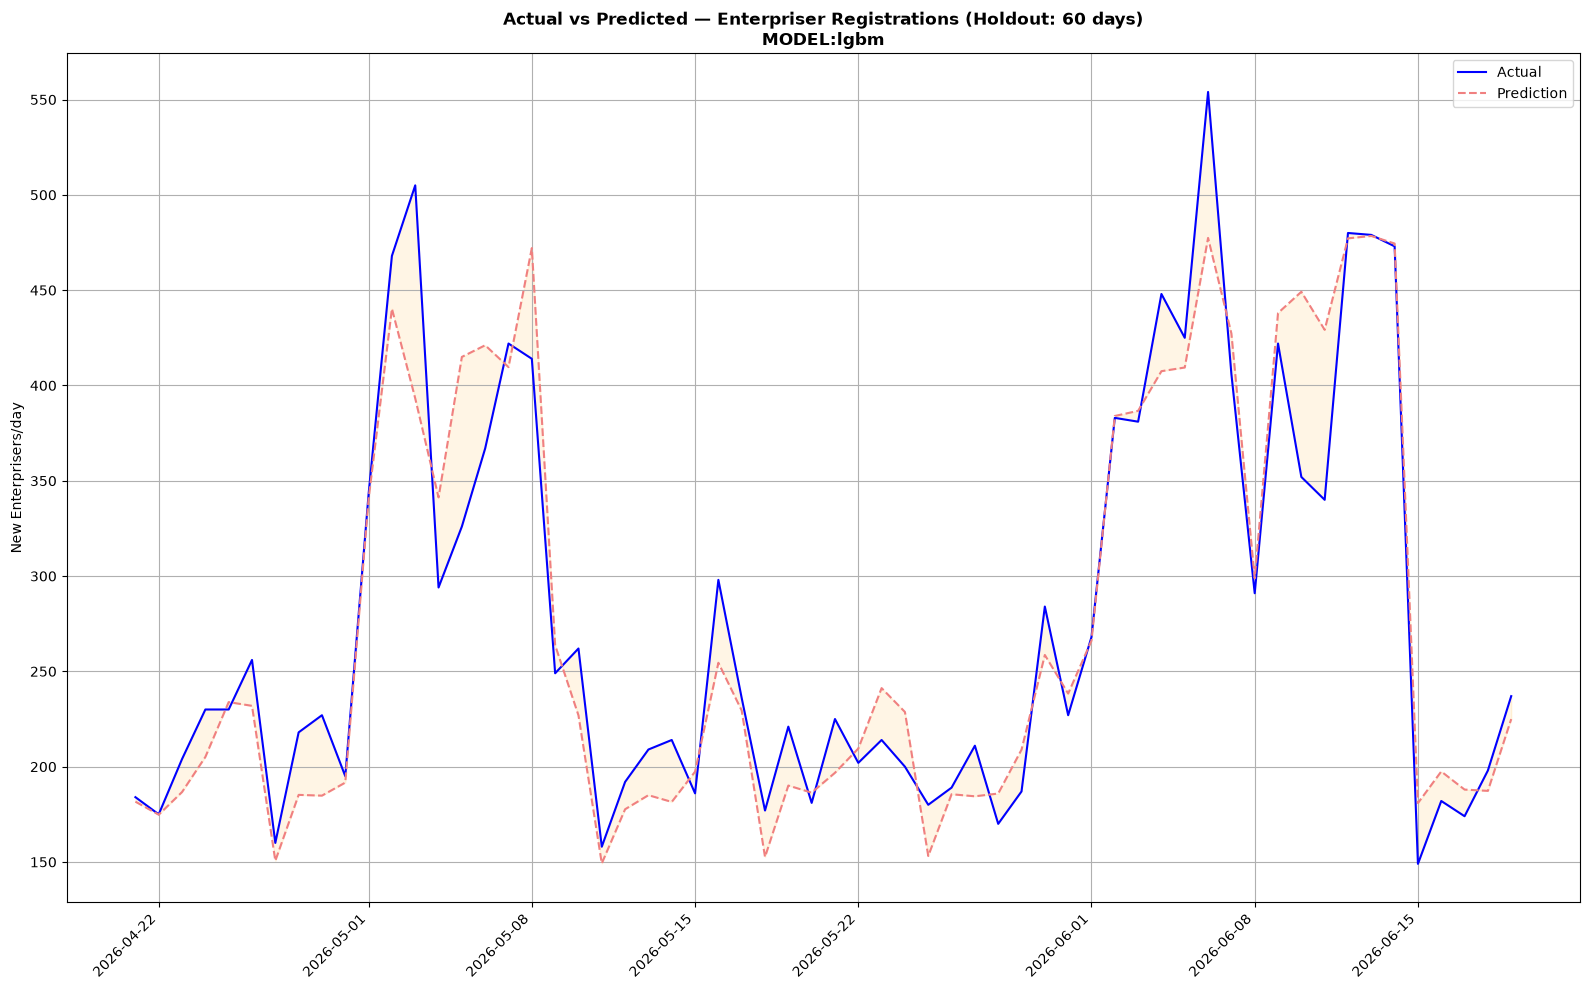

2026-06-29 23:46:13 | WARNING  | __main__ | 4289691066.py:58 | Model lgbm has no feature importance function! Skipping
2026-06-29 23:46:13 | INFO     | __main__ | 4289691066.py:64 | Model performance on training data: {'xgboost': {'mae': 0.86, 'rmse': 1.18, 'mape': 0.0}, 'lgbm': {'mae': 6.82, 'rmse': 8.73, 'mape': 0.03}, 'baseline_ridge': {'mae': 23.63, 'rmse': 30.6, 'mape': 0.11}} 
2026-06-29 23:46:13 | INFO     | __main__ | 4289691066.py:65 | Model performance on test data: {'xgboost': {'mae': 23.12, 'rmse': 31.94, 'mape': 0.08}, 'lgbm': {'mae': 24.99, 'rmse': 35.21, 'mape': 0.09}, 'baseline_ridge': {'mae': 33.95, 'rmse': 42.86, 'mape': 0.12}}


,train_mae,test_mae,train_rmse,test_rmse,train_mape,test_mape,diagnosys
model_name,,,,,,,
xgboost,0.86,23.12,1.18,31.94,0.00,0.00,Overfitting
lgbm,6.82,24.99,8.73,35.21,0.03,0.03,Weak overfitting
baseline_ridge,23.63,33.95,30.60,42.86,0.11,0.11,No overfitting


<Figure size 1600x1000 with 0 Axes>

In [24]:
DATA_DIR = PATH / "data" / "processed" 
TRAIN_FILE = DATA_DIR / "hdi_daily_ops_cleaned.csv"
FEATURE_STORE = DATA_DIR / "feature_store" / "hdi_daily_ops_feature_store.csv"
MODELS = {
    "baseline_ridge": Ridge(),
    "xgboost": XGBRegressor(),
    "lgbm": lgb.LGBMRegressor(),
}
train_compare(TRAIN_FILE, FEATURE_STORE, MODELS)

In [25]:
# because the LightGBM has a good performa relative with another model, we will use LGB model

def forecast_next_n_days(model_path:str, feature_store:str, n_days:int = 7):
    df = pd.read_csv(feature_store, parse_dates=["date"], date_format="%Y-%m-%d")
    last_date = df["date"].max()
    forecasts = []
    model = joblib.load(model_path)

    df_ext = df.copy()

    for i in range(n_days):
        future_date = last_date + pd.Timedelta(days=i + 1)
        new_row = pd.DataFrame([{
            'date': future_date,
            'new_enterpriser_count': np.nan,
            'new_bee_count': df_ext['new_bee_count'].median(),
            'is_promo_period': 0,
            'day_of_week': future_date.day_name(),
            'transaction_volume_online': df_ext['transaction_volume_online'].median(),
            'transaction_volume_offline': df_ext['transaction_volume_offline'].median(),
            'sales_ep_thousand_idr': df_ext['sales_ep_thousand_idr'].median(),
            'top_product_id': df_ext['top_product_id'].iloc[-1],
        }])
        df_ext = pd.concat([df_ext, new_row], ignore_index=True)
        df_feat = build_features(df_ext, drop_na=False)
        last_feat = df_feat[model.feature_name_ ].iloc[[-1]]
        pred = float(max(0, model.predict(last_feat)[0]))
        df_ext.loc[df_ext.index[-1], "new_enterpriser_count"] = pred

        forecasts.append({
            "date" : future_date,
            "predicted_new_enterpriser" : round(pred),
            "day_of_week" : future_date.day_name()
        })

    return forecasts
    
MODEL_PATH = PATH / "models" / "lgbm.pkl"
df_forecasts = pd.DataFrame(forecast_next_n_days(MODEL_PATH, FEATURE_STORE))
df_forecasts



,date,predicted_new_enterpriser,day_of_week
0,2026-06-20,213,Saturday
1,2026-06-21,205,Sunday
2,2026-06-22,142,Monday
3,2026-06-23,154,Tuesday
4,2026-06-24,160,Wednesday
5,2026-06-25,164,Thursday
6,2026-06-26,178,Friday
